In [1]:
import numpy as np
import numba as nb
from scipy.integrate import quad
from sympy import fourier_series, pi
from sympy import * 
import scipy.special as special
from scipy.special import i0
#import random
import math
from scipy.integrate import simpson

import matplotlib.pyplot as plt
#from scipy.stats import gaussian_kde
import h5py
import scipy.integrate as integrate
plt.rcParams['text.usetex'] = True

In [2]:
# =========================
# Parameters
# =========================

Nn = 100
L = 25.0
m = 1.0
beta = 1
lam = 1/np.sqrt(Nn)
U0 = 1
Ul = U0 * lam
g = 4
wDrive = -1
k = 2 * np.pi / L
Ulk = Ul * k

G = 10.0
Gmk = G* m*k

dt = 5e-3
tmax = 2000
nSteps = int(np.ceil(tmax / dt))
Psi0 = 1
nuc = lam**2*beta*U0**2/(Psi0*L**2)

In [3]:
# =========================
# Core rate functions
# =========================
def cyclic_next(s):
    return {"a": "b", "b": "c", "c": "a"}[s]

def cyclic_prev(s):
    return cyclic_next(cyclic_next(s))

def W_term(eta, eta_prime):
    if eta_prime == cyclic_next(eta):
        return wDrive
    elif eta_prime == cyclic_prev(eta):
        return -wDrive
    else:
        return 0.0

def UInt(x):
    return Ul*np.cos(k*x)

def dU(x):
    return -U0*lam*k*np.sin(k*x)

def Psi(x,phi):
    return Psi0*g*lam*np.cos(k*x+phi) #integrate.quad(lambda x: dPsi(x), 0, y)[0] #Psi0*gg*lam*np.exp(p*np.cos(k*x+phi)) #Psi0*gg*lam*np.cos(k*x+phi)

def dPsi(x,phi):
    return -Psi0*g*lam*k*np.sin(k*x+phi) #-gg*k*np.sin(k*x)-eps*np.tanh(np.sin(k*x))  #Psi0*gg*lam*np.exp(p*np.cos(k*x))*p*k*(-np.sin(k*x+phi)) #-Psi0*gg*lam*k*np.sin(k*x+phi)

def sX(x, eta, eta_prime):
    Ueta = UInt(x) if eta == "a" else 0.0
    Ueta_p = UInt(x) if eta_prime == "a" else 0.0
    return beta * (Ueta - Ueta_p+ W_term(eta, eta_prime)) ## add work contribution

def kRate(x, eta, eta_prime):
    if eta == eta_prime:
        return 0.0

    # Reactivities
    if eta == "a" and eta_prime == "b":
        psi = Psi0 * (1 + lam * g * np.cos(k * x+phi))
    elif eta == "b" and eta_prime == "a":
        psi = Psi0 * (1 + lam * g * np.cos(k * x+phi))
    else:
        psi = Psi0

    return psi*np.exp(sX(x, eta, eta_prime)/2.0)
def nu(x,w, phi):
    A=2*beta*np.cosh(beta*w/2)*(np.cosh(beta*w)+2)
    B = np.exp(-beta*w/2)*(np.exp(2*beta*w)+np.exp(beta*w)-2)
    return (A*(dU(x))**2+B*dU(x)*dPsi(x,phi))/(9*Psi0*(2*np.cosh(beta*w)+1)**2)
def nu2(x,w, phi):
    A2= 8*np.pi**2*lam**2/(9*(2*np.cosh(beta*w)+1)**2)*np.cosh(beta*w/2)*(np.cosh(beta*w)+2)*beta*U0**2/(Psi0*L**2)
    B2 = 4*np.pi**2*lam**2/(9*(2*np.cosh(beta*w)+1)**2)*np.exp(-beta*w/2)*(np.exp(2*beta*w)+np.exp(beta*w)-2)*g*U0/(Psi0*L**2)
    R = np.sqrt(A2**2+B2**2+2*A2*B2*np.cos(phi))/2
    delta = np.arctan2(B2*np.sin(phi),-A2-B2*np.cos(phi))
    return (A2+B2*np.cos(phi))/2+R*np.cos(4*np.pi*x/L-delta)
    

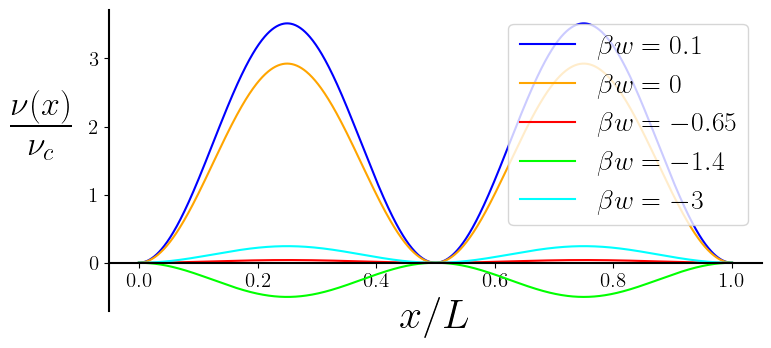

In [14]:
xL=np.linspace(0,L,1000)
fig, ax = plt.subplots(figsize=(8, 4))
#plt.hist(xredstation, bins = "auto", density = True, label = "Reduced dynamics")
plt.plot(xL/L, nu(xL,0.1,0)/nuc, label = r"$\beta w = 0.1$", color = 'blue')
plt.plot(xL/L, nu(xL,0,0)/nuc, label = r"$\beta w = 0$", color = 'orange')
plt.plot(xL/L, nu(xL,-0.65,0)/nuc, label = r"$\beta w = -0.65$", color = 'red')
plt.plot(xL/L, nu(xL,-1.4,0)/nuc, label = r"$\beta w = -1.4$", color = 'lime')
plt.plot(xL/L, nu(xL,-3.5,0)/nuc, label = r"$\beta w = -3$", color = 'cyan')
#plt.plot(xL/L, nu2(xL,-1,0)/nuc, label = r"$\beta w = -1$", linestyle = '--', color = 'black')
#plt.plot(xL/L, nu2(xL,-0.5,0)/nuc, label = r"$\beta w = -1$", linestyle = '--', color = 'black')
#plt.plot(xL/L, nu2(xL,0,0)/nuc, label = r"$\beta w = -1$", linestyle = '--', color = 'black')
#plt.plot(xL/L, nu2(xL,1,0)/nuc, label = r"$\beta w = -1$", linestyle = '--', color = 'black')

#plt.plot(xL/L, nu(xL,1,0)/nuc, label = r"$\beta w = 1$")
ax.set_ylabel(r"$\frac{\nu(x)}{\nu_c}$", fontsize = 35, rotation = 0,labelpad=35)
ax.set_xlabel(r"$x/L$", fontsize = 30)
#ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
ax.legend(fontsize = 20, loc = 'upper right')
plt.tight_layout()
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=15)
for axis in 'left', 'bottom':
    ax.spines[axis].set_linewidth(1.5)
# Move x-axis to y = 0
ax.spines['bottom'].set_position(('data', 0))

# Optional: hide the top spine
#ax.spines['top'].set_visible(False)

# Ensure ticks are on the moved axis
ax.xaxis.set_ticks_position('bottom')
#plt.savefig('nuwf2.png')
plt.show()


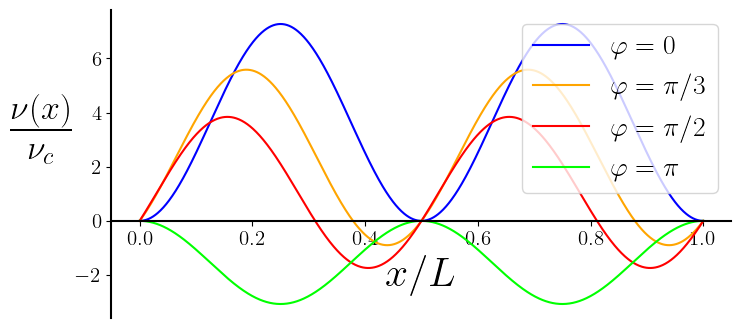

In [19]:
xL=np.linspace(0,L,1000)
fig, ax = plt.subplots(figsize=(8, 4))
#plt.hist(xredstation, bins = "auto", density = True, label = "Reduced dynamics")
plt.plot(xL/L, nu(xL,1,0)/nuc, label = r"$\varphi = 0$", color = 'blue')
plt.plot(xL/L, nu(xL,1,np.pi/3)/nuc, label = r"$\varphi = \pi/3$", color = 'orange')
plt.plot(xL/L, nu(xL,1,np.pi/2)/nuc, label = r"$\varphi = \pi/2$", color = 'red')
plt.plot(xL/L, nu(xL,1,np.pi)/nuc, label = r"$\varphi = \pi$", color = 'lime')
ax.set_ylabel(r"$\frac{\nu(x)}{\nu_c}$", fontsize = 35, rotation = 0,labelpad=25)
ax.set_xlabel(r"$x/L$", fontsize = 30)
#ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
ax.legend(fontsize = 20, loc = 'upper right')
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=15)
for axis in 'left', 'bottom':
    ax.spines[axis].set_linewidth(1.5)
# Move x-axis to y = 0
ax.spines['bottom'].set_position(('data', 0))

# Optional: hide the top spine
#ax.spines['top'].set_visible(False)

# Ensure ticks are on the moved axis
ax.xaxis.set_ticks_position('bottom')
plt.savefig('nuphif2.png')
plt.show()